# Playground — Feature Selection Experiment
**Question:** does using only the most important features *hurt or help* our LightGBM?

We train the full 41-feature model → rank features by SHAP + gain importance → retrain
with top-K subsets (K = 10, 15, 20, 25, 30) → compare pinball loss q=0.45, MAE, and
coverage on the 2025 holdout year.

Both DE-LU and ES are evaluated independently; results are shown side-by-side.


In [4]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

REPO = Path().resolve()
sys.path.insert(0, str(REPO / "src"))

from model import FEATURES, TARGET, ZONES, QUANTILES

# Time splits (mirror model.py)
TRAIN_START = "2023-05-01"
TRAIN_END   = "2025-01-01"
VAL_END     = "2026-01-01"

print(f"Full feature count: {len(FEATURES)}")
print("Features:", FEATURES[:6], "...")


Full feature count: 62
Features: ['load', 'wind_generation', 'solar_generation', 'hydro_generation', 'nuclear_generation', 'temperature'] ...


## 1. Load Dataset

We load `data/processed/final_dataset.parquet` — the same 41-column DataFrame the
production model uses. No re-running the pipeline needed.


In [8]:
data_path = REPO / "data" / "processed" / "final_dataset.parquet"
df = pd.read_parquet(data_path)
df = df.reset_index()

# Ensure timestamp column
if "timestamp" not in df.columns and df.index.name == "timestamp":
    df = df.reset_index()

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print(f"Rows: {len(df):,}   Zones: {df['zone'].unique()}")
print(f"Columns: {list(df.columns[:10])} ...")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")


Rows: 52,594   Zones: ['DE-LU' 'ES']
Columns: ['timestamp', 'zone', 'price', 'wind_generation', 'solar_generation', 'hydro_generation', 'nuclear_generation', 'load', 'DE_wind_wind_speed_100m', 'DE_solar_shortwave_radiation'] ...
Date range: 2023-05-08 00:00:00+00:00 → 2026-05-07 22:00:00+00:00


## 2. Baseline Model — All 41 Features

Train three quantile models (q=0.025, q=0.45, q=0.975) per zone on the training window
(2023-05-01 → 2025-01-01), then evaluate on the 2025 holdout (2025-01-01 → 2026-01-01).

We store:
- Pinball loss at q=0.45 (competition metric)
- MAE at p50
- 95% interval coverage
- Feature importances (gain + split)


In [9]:
def pinball(y, yhat, q):
    e = y - yhat
    return np.where(e >= 0, q * e, (q - 1) * e).mean()

def coverage(y, lo, hi):
    return ((y >= lo) & (y <= hi)).mean()

LGB_PARAMS = dict(
    objective="quantile",
    metric="quantile",
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=800,
    verbose=-1,
    n_jobs=-1,
    random_state=42,
)

def train_eval(zone_df, features, label="full"):
    train = zone_df[zone_df["timestamp"] < TRAIN_END]
    val   = zone_df[(zone_df["timestamp"] >= TRAIN_END) & (zone_df["timestamp"] < VAL_END)]

    train = train.dropna(subset=[TARGET])
    val   = val.dropna(subset=[TARGET])

    X_tr, y_tr = train[features], train[TARGET]
    X_va, y_va = val[features],   val[TARGET]

    models = {}
    preds  = {}
    for q in QUANTILES:
        m = lgb.LGBMRegressor(**{**LGB_PARAMS, "alpha": q})
        m.fit(X_tr, y_tr)
        models[q] = m
        preds[q]  = m.predict(X_va)

    pb  = pinball(y_va.values, preds[0.45], 0.45)
    mae = mean_absolute_error(y_va, preds[0.45])
    cov = coverage(y_va.values, preds[0.025], preds[0.975])

    # Gain importance from p50 model
    imp = pd.Series(
        models[0.45].booster_.feature_importance(importance_type="gain"),
        index=features
    ).sort_values(ascending=False)

    return {"pinball": pb, "mae": mae, "coverage": cov, "models": models,
            "preds": preds, "y_val": y_va, "val_idx": val["timestamp"],
            "importance": imp, "features": features}

# Separate by zone
baseline = {}
for zone in ZONES:
    zdf = df[df["zone"] == zone].sort_values("timestamp").copy()
    print(f"Training {zone} baseline ({len(FEATURES)} features)...")
    baseline[zone] = train_eval(zdf, FEATURES, label="full")
    r = baseline[zone]
    print(f"  {zone}: Pinball={r['pinball']:.3f}  MAE={r['mae']:.2f}  Coverage={r['coverage']:.1%}")


Training DE-LU baseline (62 features)...
  DE-LU: Pinball=3.398  MAE=7.00  Coverage=76.7%
Training ES baseline (62 features)...
  ES: Pinball=3.064  MAE=6.15  Coverage=72.1%


## 3. Feature Importance — Gain + SHAP

We rank features two ways:
1. **Gain importance** — total information gain from LightGBM splits (built-in)
2. **SHAP mean |φ|** — model-agnostic, measures average impact on prediction magnitude

Features consistently ranking low in both are candidates for pruning.


In [10]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

shap_vals = {}
shap_rank = {}

for zone in ZONES:
    zdf   = df[df["zone"] == zone].sort_values("timestamp").copy()
    val   = zdf[(zdf["timestamp"] >= TRAIN_END) & (zdf["timestamp"] < VAL_END)].dropna(subset=[TARGET])
    X_va  = val[FEATURES]

    # Sample 600 rows for speed
    rng  = np.random.default_rng(0)
    idx  = rng.choice(len(X_va), size=min(600, len(X_va)), replace=False)
    X_s  = X_va.iloc[idx]

    explainer = shap.TreeExplainer(baseline[zone]["models"][0.45])
    sv        = explainer.shap_values(X_s)
    shap_vals[zone] = sv
    shap_rank[zone] = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)
    print(f"{zone} — top 10 SHAP:")
    print(shap_rank[zone].head(10).to_string())
    print()


DE-LU — top 10 SHAP:
lag_1                          28.207375
residual_load_ramp_forecast     4.300593
residual_load_ramp              3.344280
residual_load                   3.324968
residual_load_forecast          2.206969
hydro_generation                1.441294
lag_168                         1.000789
lag_24                          0.774971
CH_price_lag24                  0.715175
price_roll_24h                  0.683181

ES — top 10 SHAP:
lag_1                          32.015924
residual_load_ramp_forecast     3.194036
residual_load_ramp              2.856526
residual_load_forecast          2.841632
price_roll_24h                  2.731620
lag_24                          1.239053
price_roll_168h                 0.806599
coal_price                      0.767313
residual_load                   0.644227
lag_168                         0.512292



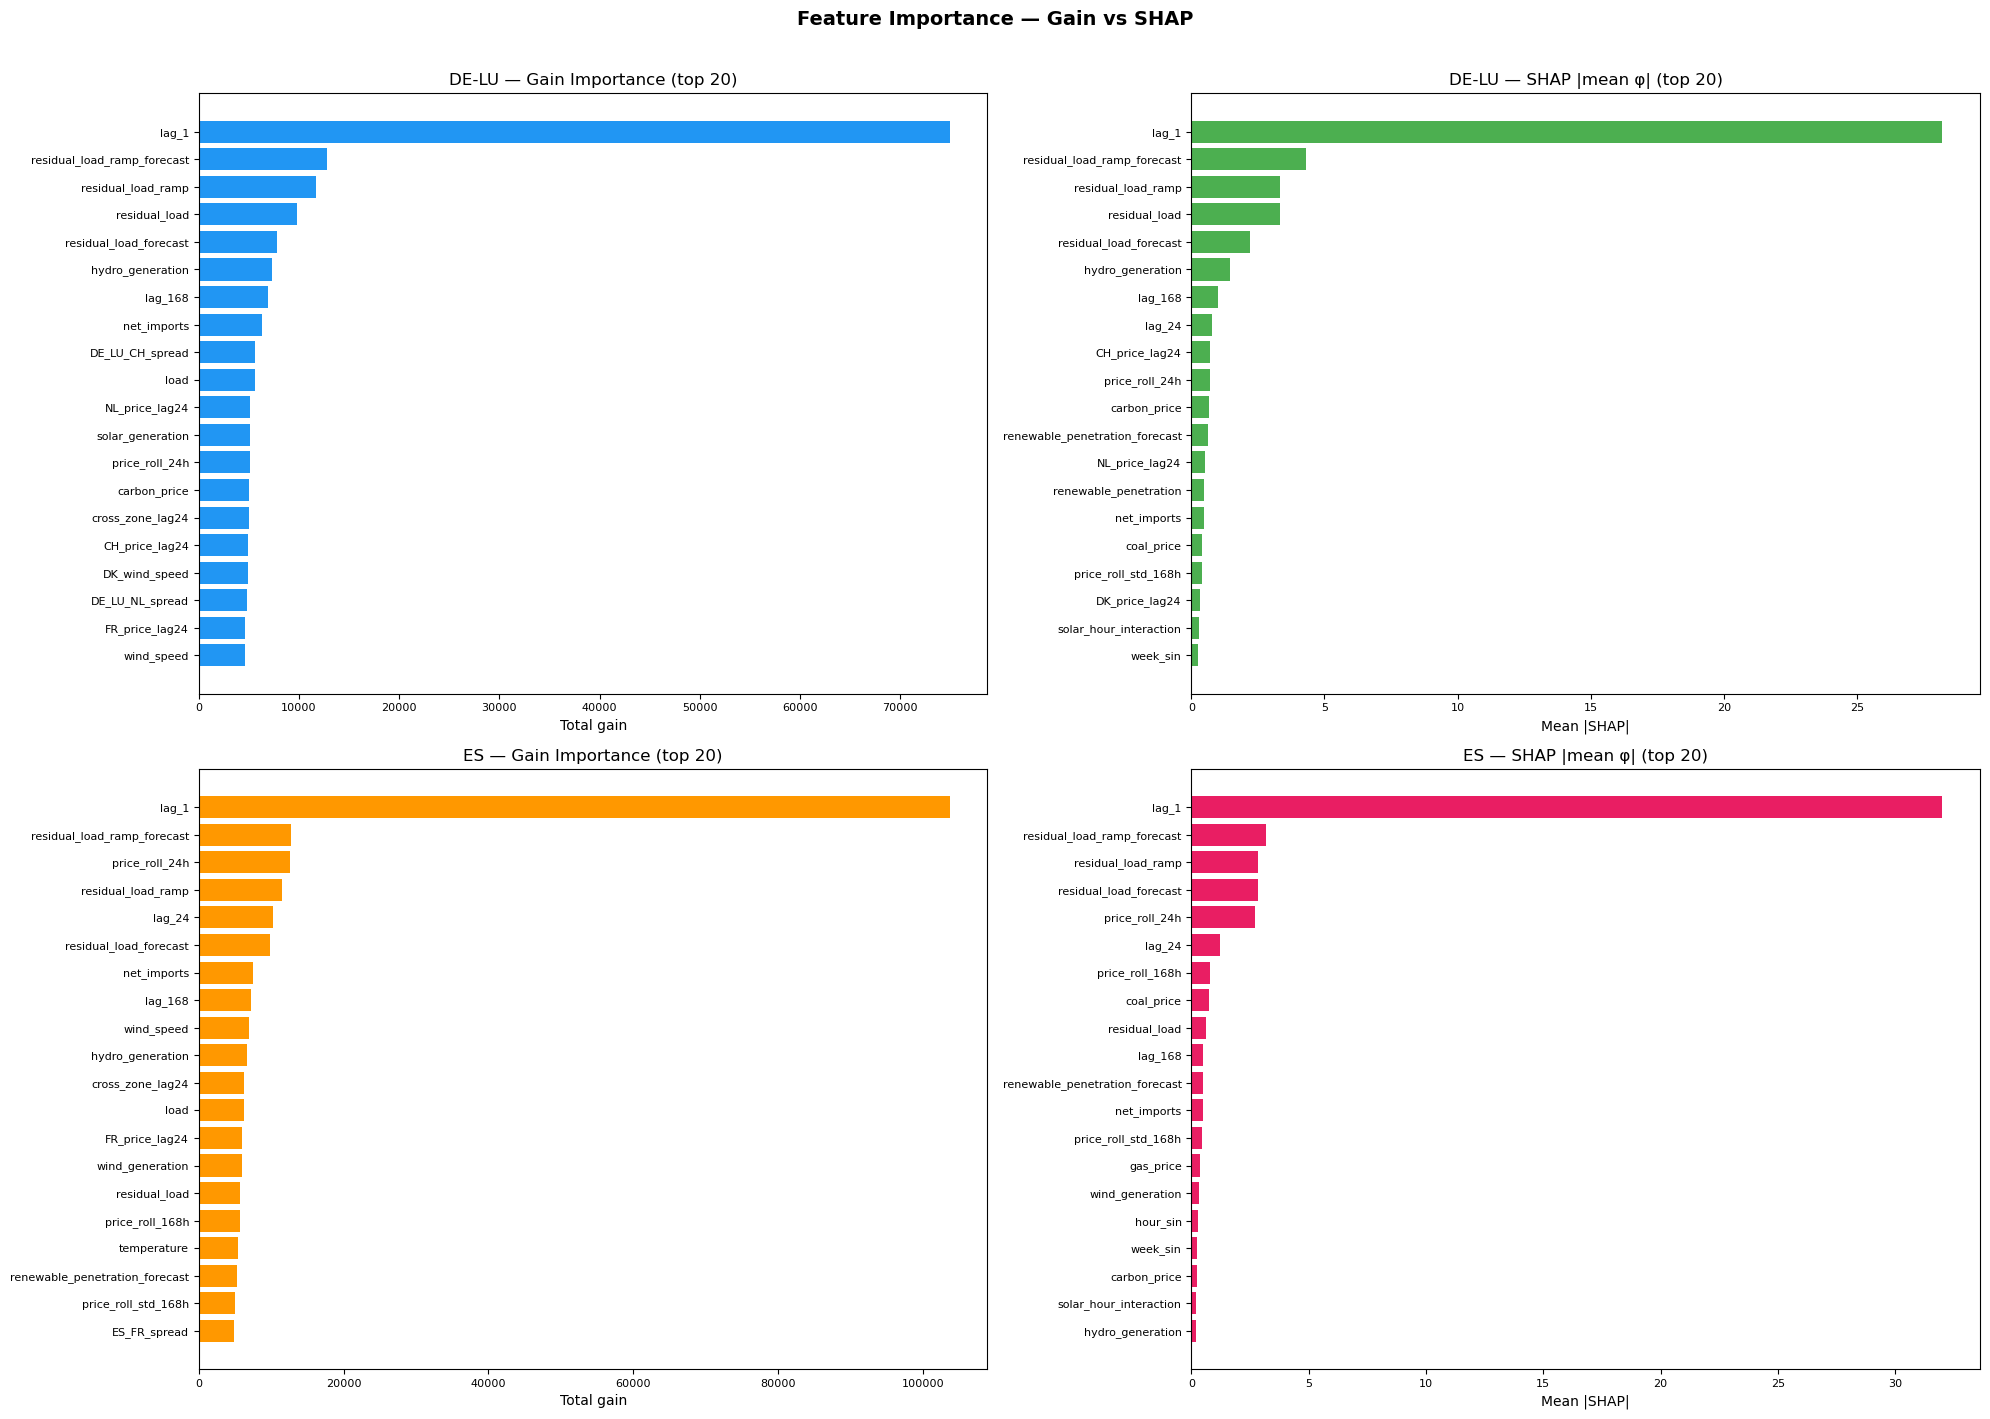

In [11]:
# Side-by-side importance charts
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for row, zone in enumerate(ZONES):
    # Gain
    imp = baseline[zone]["importance"].head(20)
    axes[row, 0].barh(imp.index[::-1], imp.values[::-1], color="#2196F3" if zone == "DE-LU" else "#FF9800")
    axes[row, 0].set_title(f"{zone} — Gain Importance (top 20)")
    axes[row, 0].set_xlabel("Total gain")
    axes[row, 0].tick_params(labelsize=8)

    # SHAP
    sv = shap_rank[zone].head(20)
    axes[row, 1].barh(sv.index[::-1], sv.values[::-1], color="#4CAF50" if zone == "DE-LU" else "#E91E63")
    axes[row, 1].set_title(f"{zone} — SHAP |mean φ| (top 20)")
    axes[row, 1].set_xlabel("Mean |SHAP|")
    axes[row, 1].tick_params(labelsize=8)

plt.suptitle("Feature Importance — Gain vs SHAP", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPO / "playground_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Rank Fusion — Combined Importance Score

We combine gain rank and SHAP rank using **Borda count** (average of normalised ranks).
This gives a single ordering robust to the quirks of either metric alone.

Features with score < 5% of the top feature are flagged as low-value candidates.


In [12]:
combined_rank = {}

for zone in ZONES:
    gain_rank = baseline[zone]["importance"].rank(ascending=False)
    shap_r    = shap_rank[zone].rank(ascending=False)

    # Align (same index = FEATURES)
    borda = (gain_rank + shap_r) / 2
    borda = borda.sort_values()

    # Normalised score 0–1 (1 = best)
    score = 1 - (borda - borda.min()) / (borda.max() - borda.min())
    combined_rank[zone] = score.sort_values(ascending=False)

# Print ranked table
print(f"{'Feature':<38}  {'DE-LU':>8}  {'ES':>8}")
print("-" * 58)
all_feats = list(dict.fromkeys(
    list(combined_rank['DE-LU'].index) + list(combined_rank['ES'].index)
))
for f in all_feats:
    delu = combined_rank['DE-LU'].get(f, 0)
    es   = combined_rank['ES'].get(f, 0)
    flag = " ←low" if delu < 0.05 and es < 0.05 else ""
    print(f"{f:<38}  {delu:>8.3f}  {es:>8.3f}{flag}")


Feature                                    DE-LU        ES
----------------------------------------------------------
lag_1                                      1.000     1.000
residual_load_ramp_forecast                0.983     0.981
residual_load_ramp                         0.965     0.952
residual_load                              0.948     0.790
residual_load_forecast                     0.930     0.924
hydro_generation                           0.913     0.733
lag_168                                    0.896     0.848
net_imports                                0.817     0.838
price_roll_24h                             0.817     0.943
NL_price_lag24                             0.809     0.000
carbon_price                               0.800     0.610
CH_price_lag24                             0.800     0.000
load                                       0.739     0.610
solar_generation                           0.730     0.505
renewable_penetration_forecast             0.730     0.7

## 5. Feature Selection Sweep — K = 10, 15, 20, 25, 30

For each K, we:
1. Take the top-K features by combined Borda rank (per zone)
2. Retrain from scratch with only those features
3. Record pinball q=0.45, MAE, coverage

This tells us whether our 41-feature model is over-specified or whether each feature
is pulling its weight.


In [13]:
K_VALUES = [10, 15, 20, 25, 30, len(FEATURES)]  # last = baseline

results = {zone: [] for zone in ZONES}

for zone in ZONES:
    zdf = df[df["zone"] == zone].sort_values("timestamp").copy()
    ranked_feats = combined_rank[zone].index.tolist()  # best first

    for k in K_VALUES:
        feats = ranked_feats[:k]
        label = f"top-{k}" if k < len(FEATURES) else "all-41"
        res   = train_eval(zdf, feats, label=label)
        results[zone].append({
            "k": k,
            "label": label,
            "pinball": res["pinball"],
            "mae": res["mae"],
            "coverage": res["coverage"],
        })
        print(f"{zone} k={k:>2}: Pinball={res['pinball']:.3f}  MAE={res['mae']:.2f}  Coverage={res['coverage']:.1%}")
    print()

results_df = {zone: pd.DataFrame(results[zone]).set_index("k") for zone in ZONES}


DE-LU k=10: Pinball=3.413  MAE=6.92  Coverage=79.6%
DE-LU k=15: Pinball=3.396  MAE=6.89  Coverage=75.7%
DE-LU k=20: Pinball=3.449  MAE=7.02  Coverage=77.5%
DE-LU k=25: Pinball=3.416  MAE=7.00  Coverage=77.2%
DE-LU k=30: Pinball=3.495  MAE=7.21  Coverage=77.6%
DE-LU k=62: Pinball=3.425  MAE=7.07  Coverage=77.0%

ES k=10: Pinball=3.082  MAE=6.17  Coverage=75.7%
ES k=15: Pinball=3.046  MAE=6.02  Coverage=76.4%
ES k=20: Pinball=3.322  MAE=6.58  Coverage=72.7%
ES k=25: Pinball=3.123  MAE=6.25  Coverage=72.7%
ES k=30: Pinball=3.138  MAE=6.27  Coverage=72.4%
ES k=62: Pinball=3.297  MAE=6.56  Coverage=74.4%



## 6. Results Table


In [14]:
for zone in ZONES:
    r = results_df[zone].copy()
    baseline_pb  = r.loc[len(FEATURES), "pinball"]
    baseline_mae = r.loc[len(FEATURES), "mae"]
    r["pinball_delta"] = r["pinball"] - baseline_pb
    r["mae_delta"]     = r["mae"] - baseline_mae
    print(f"\n{'='*60}")
    print(f"  {zone}")
    print(f"{'='*60}")
    print(r[["label", "pinball", "pinball_delta", "mae", "mae_delta", "coverage"]].to_string(
        formatters={
            "pinball":       "{:.3f}".format,
            "pinball_delta": lambda x: f"{x:+.3f}",
            "mae":           "{:.2f}".format,
            "mae_delta":     lambda x: f"{x:+.2f}",
            "coverage":      "{:.1%}".format,
        }
    ))



  DE-LU
     label pinball pinball_delta  mae mae_delta coverage
k                                                       
10  top-10   3.413        -0.012 6.92     -0.15    79.6%
15  top-15   3.396        -0.030 6.89     -0.18    75.7%
20  top-20   3.449        +0.024 7.02     -0.05    77.5%
25  top-25   3.416        -0.009 7.00     -0.07    77.2%
30  top-30   3.495        +0.070 7.21     +0.14    77.6%
62  all-41   3.425        +0.000 7.07     +0.00    77.0%

  ES
     label pinball pinball_delta  mae mae_delta coverage
k                                                       
10  top-10   3.082        -0.215 6.17     -0.39    75.7%
15  top-15   3.046        -0.251 6.02     -0.54    76.4%
20  top-20   3.322        +0.025 6.58     +0.02    72.7%
25  top-25   3.123        -0.174 6.25     -0.31    72.7%
30  top-30   3.138        -0.159 6.27     -0.29    72.4%
62  all-41   3.297        +0.000 6.56     +0.00    74.4%


## 7. Visual Comparison


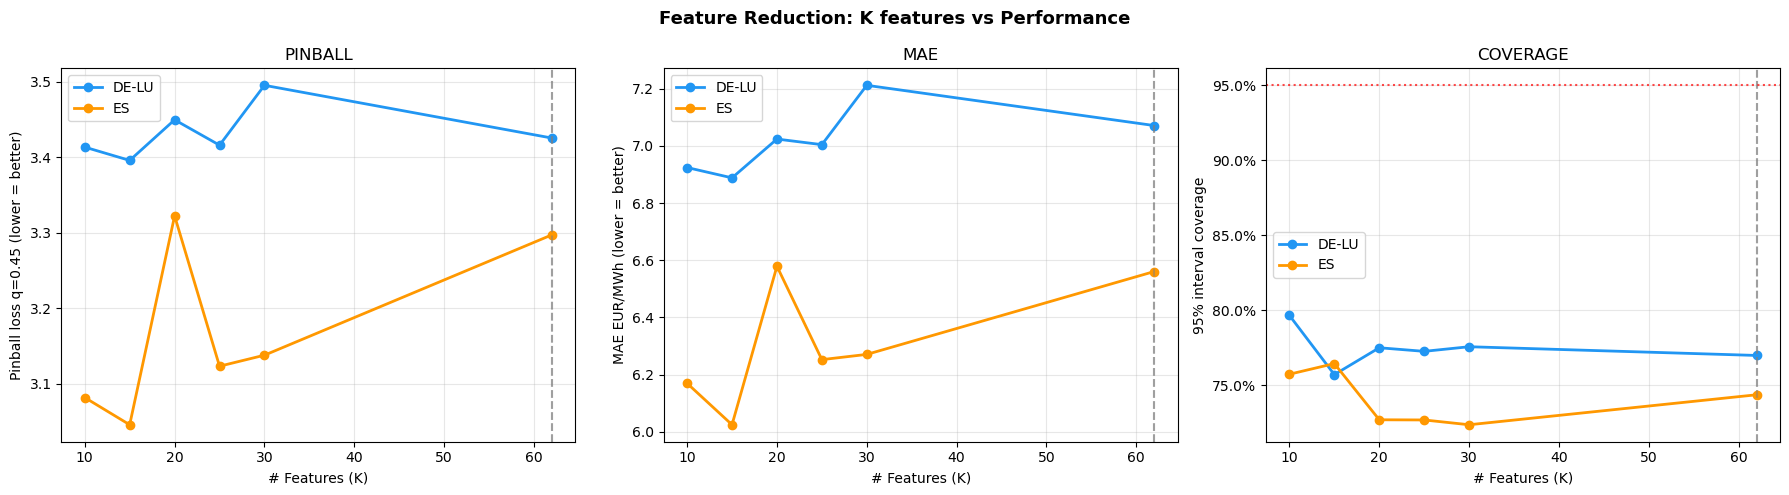

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"DE-LU": "#2196F3", "ES": "#FF9800"}

for ax_idx, metric in enumerate(["pinball", "mae", "coverage"]):
    ax = axes[ax_idx]
    for zone in ZONES:
        r   = results_df[zone]
        ks  = r.index.tolist()
        vals = r[metric].tolist()
        ax.plot(ks, vals, marker="o", label=zone, color=colors[zone], linewidth=2)
        # Mark baseline (all-41)
        ax.axvline(len(FEATURES), color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("# Features (K)")
    ax.set_title(metric.upper().replace("_", " "))
    ax.legend()
    ax.grid(True, alpha=0.3)
    if metric == "coverage":
        ax.axhline(0.95, color="red", linestyle=":", alpha=0.7, label="target 95%")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

axes[0].set_ylabel("Pinball loss q=0.45 (lower = better)")
axes[1].set_ylabel("MAE EUR/MWh (lower = better)")
axes[2].set_ylabel("95% interval coverage")

plt.suptitle("Feature Reduction: K features vs Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPO / "playground_feature_sweep.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. What Gets Dropped at Each K?

Shows which features are *excluded* when we move from all-41 down to the top-K subsets.
Useful for understanding which signals are genuinely redundant.


In [16]:
print("Features DROPPED when using top-K (union of both zones):")
print()

for k in [10, 15, 20, 25, 30]:
    dropped = set()
    for zone in ZONES:
        ranked = combined_rank[zone].index.tolist()
        dropped |= set(ranked[k:])

    kept_both = set()
    for zone in ZONES:
        ranked = combined_rank[zone].index.tolist()
        kept_both |= set(ranked[:k])

    actually_dropped = set(FEATURES) - kept_both
    print(f"K={k:>2} → drops {len(actually_dropped):>2} features:")
    for f in sorted(actually_dropped):
        delu = combined_rank['DE-LU'].get(f, 0)
        es   = combined_rank['ES'].get(f, 0)
        print(f"  - {f:<38} DE-LU={delu:.3f}  ES={es:.3f}")
    print()


Features DROPPED when using top-K (union of both zones):

K=10 → drops 50 features:
  - CH_precip_7d_sum                       DE-LU=0.513  ES=0.000
  - CH_precipitation                       DE-LU=0.278  ES=0.000
  - CH_price_lag24                         DE-LU=0.800  ES=0.000
  - DE_LU_CH_spread                        DE-LU=0.600  ES=0.000
  - DE_LU_FR_spread                        DE-LU=0.557  ES=0.000
  - DE_LU_NL_spread                        DE-LU=0.530  ES=0.000
  - DK_price_lag24                         DE-LU=0.652  ES=0.000
  - DK_wind_speed                          DE-LU=0.583  ES=0.000
  - DK_wind_speed_cubed                    DE-LU=0.313  ES=0.000
  - ES_FR_spread                           DE-LU=0.000  ES=0.552
  - ES_hydro_precip_7d_sum                 DE-LU=0.000  ES=0.448
  - ES_hydro_precipitation                 DE-LU=0.000  ES=0.295
  - FR_price_lag24                         DE-LU=0.530  ES=0.590
  - carbon_price                           DE-LU=0.800  ES=0.610
  - co

## 9. Recommendation

Which K minimises pinball loss with the fewest features?

We also show the **efficiency frontier**: features-per-unit-improvement in pinball vs baseline.


In [17]:
print("Efficiency analysis (Δpinball per feature dropped vs baseline):")
print(f"{'K':>4}  {'DE-LU Δpb':>12}  {'ES Δpb':>10}  {'Avg Δpb':>10}  {'Verdict'}")
print("-" * 60)

for k in K_VALUES:
    delu_delta = results_df["DE-LU"].loc[k, "pinball"] - results_df["DE-LU"].loc[len(FEATURES), "pinball"]
    es_delta   = results_df["ES"].loc[k, "pinball"]   - results_df["ES"].loc[len(FEATURES), "pinball"]
    avg        = (delu_delta + es_delta) / 2
    feats_saved = len(FEATURES) - k
    verdict = "✓ leaner & better" if avg < -0.01 else ("≈ no change" if abs(avg) < 0.05 else "✗ worse")
    print(f"{k:>4}  {delu_delta:>+12.3f}  {es_delta:>+10.3f}  {avg:>+10.3f}  {verdict}")

print()
best_k_delu = results_df["DE-LU"]["pinball"].idxmin()
best_k_es   = results_df["ES"]["pinball"].idxmin()
print(f"Best K for DE-LU: {best_k_delu} features (pinball={results_df['DE-LU'].loc[best_k_delu,'pinball']:.3f})")
print(f"Best K for ES:    {best_k_es} features (pinball={results_df['ES'].loc[best_k_es,'pinball']:.3f})")
print()
print("If best-K < 41 → consider pruning low-rank features from production model.")
print("If best-K = 41 → all features contribute; keep the full set.")


Efficiency analysis (Δpinball per feature dropped vs baseline):
   K     DE-LU Δpb      ES Δpb     Avg Δpb  Verdict
------------------------------------------------------------
  10        -0.012      -0.215      -0.114  ✓ leaner & better
  15        -0.030      -0.251      -0.140  ✓ leaner & better
  20        +0.024      +0.025      +0.025  ≈ no change
  25        -0.009      -0.174      -0.092  ✓ leaner & better
  30        +0.070      -0.159      -0.045  ✓ leaner & better
  62        +0.000      +0.000      +0.000  ≈ no change

Best K for DE-LU: 15 features (pinball=3.396)
Best K for ES:    15 features (pinball=3.046)

If best-K < 41 → consider pruning low-rank features from production model.
If best-K = 41 → all features contribute; keep the full set.
